In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 80, 3, padding=1, groups=20),
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 80, 1),   # pointwise conv
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 60, 3, padding=1, groups=20),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model34_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model34_0)
describe(model34_0)

MACs: 4.84 MMac, Params: 30.73 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model34_0.pt
Starting
Epoch 1/60: Train loss = 1.1058, Train accuracy = 0.6037, Test loss = 1.0799, Test accuracy = 0.6152
Epoch 2/60: Train loss = 1.0051, Train accuracy = 0.6554, Test loss = 0.9495, Test accuracy = 0.6730
Epoch 3/60: Train loss = 0.7843, Train accuracy = 0.7262, Test loss = 0.7963, Test accuracy = 0.7278
Epoch 4/60: Train loss = 0.7078, Train accuracy = 0.7531, Test loss = 0.7080, Test accuracy = 0.7580
Epoch 5/60: Train loss = 0.7096, Train accuracy = 0.7518, Test loss = 0.7476, Test accuracy = 0.7452
Epoch 6/60: Train loss = 0.7709, Train accuracy = 0.7391, Test loss = 0.8182, Test accuracy = 0.7284
Epoch 7/60: Train loss = 0.7021, Train accuracy = 0.7637, Test loss = 0.7219, Test accuracy = 0.7632
Epoch 8/60: Train loss = 0.8134, Train accuracy = 0.7172, Test loss = 0.8579, Test accuracy = 0.7091
Epoch 9/60: Train loss = 0.5814, Train accuracy = 0.7973, Test loss = 0.6527, Test accuracy = 0.7862
Epoch 10/60: Train loss = 0.659

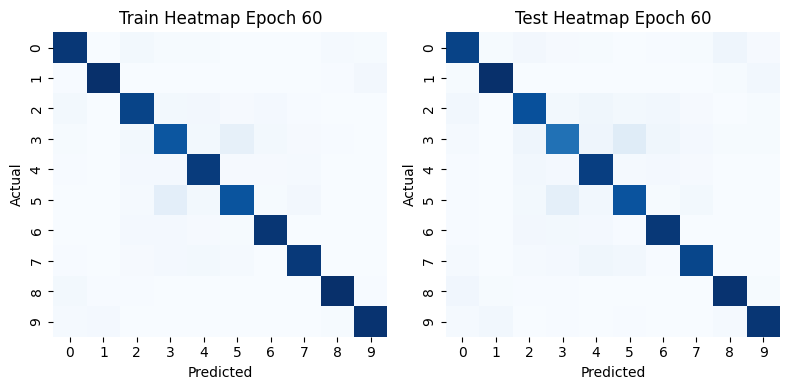

<Figure size 1200x600 with 0 Axes>

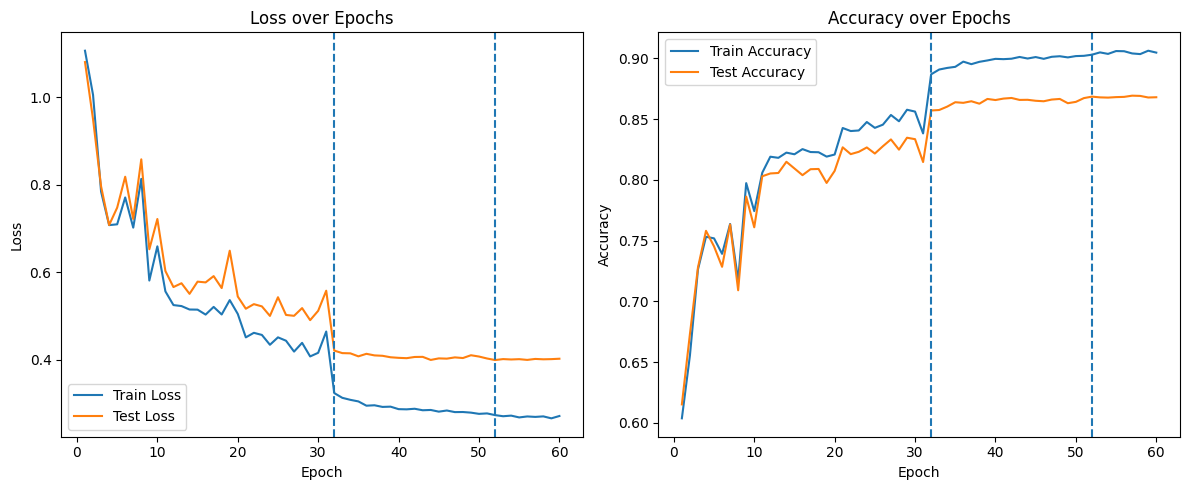

In [6]:
trainf32(model34_0,"model_weights/model34_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model34_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model34_1)
describe(model34_1)

MACs: 4.84 MMac, Params: 30.73 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model34_1.pt
Starting
Epoch 1/60: Train loss = 1.1477, Train accuracy = 0.6037, Test loss = 1.1398, Test accuracy = 0.6094
Epoch 2/60: Train loss = 0.8958, Train accuracy = 0.6979, Test loss = 0.8998, Test accuracy = 0.7018
Epoch 3/60: Train loss = 0.7513, Train accuracy = 0.7378, Test loss = 0.7346, Test accuracy = 0.7452
Epoch 4/60: Train loss = 0.6942, Train accuracy = 0.7569, Test loss = 0.6999, Test accuracy = 0.7582
Epoch 5/60: Train loss = 0.6790, Train accuracy = 0.7637, Test loss = 0.7264, Test accuracy = 0.7601
Epoch 6/60: Train loss = 0.6265, Train accuracy = 0.7826, Test loss = 0.6491, Test accuracy = 0.7819
Epoch 7/60: Train loss = 0.6874, Train accuracy = 0.7684, Test loss = 0.7398, Test accuracy = 0.7588
Epoch 8/60: Train loss = 0.5683, Train accuracy = 0.8027, Test loss = 0.6018, Test accuracy = 0.7965
Epoch 9/60: Train loss = 0.5679, Train accuracy = 0.8019, Test loss = 0.5917, Test accuracy = 0.7970
Epoch 10/60: Train loss = 0.540

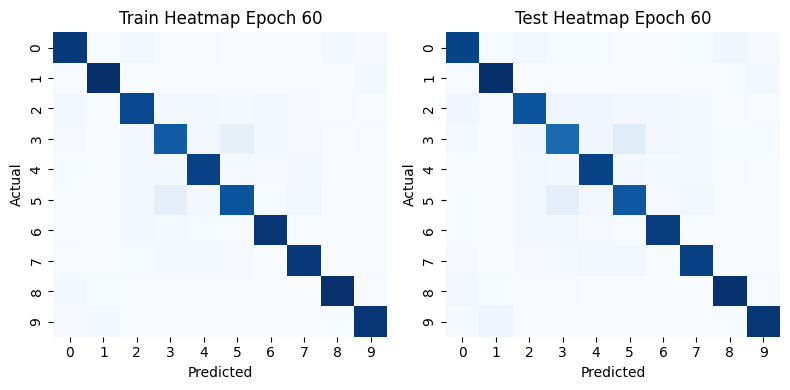

<Figure size 1200x600 with 0 Axes>

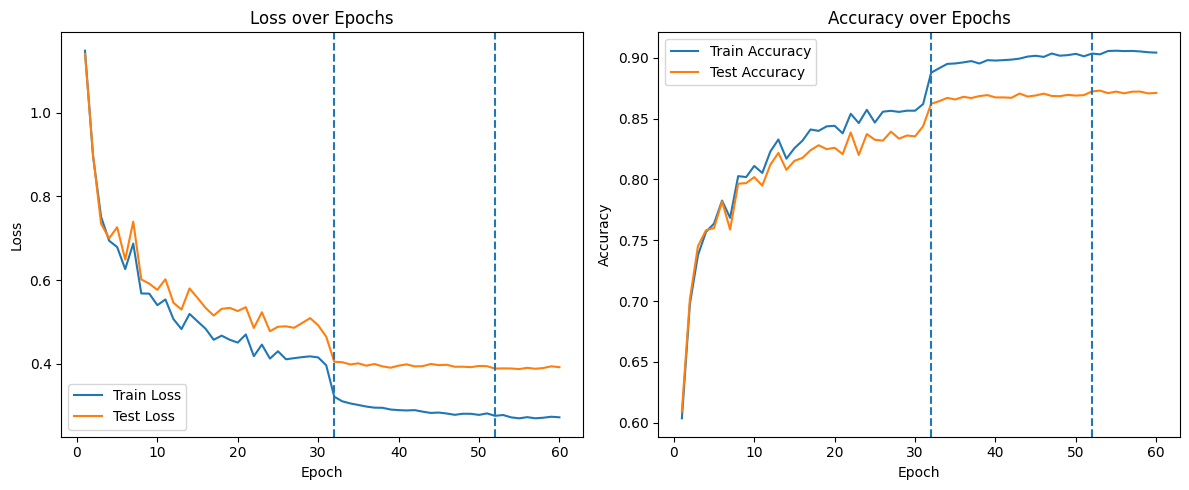

In [8]:
trainf32(model34_1,"model_weights/model34_1.pt",criterion,train_dataset,val_dataset, batch_size=64)